# UR5 – Cinemática Inversa com Python + CoppeliaSim
### ENGA73 – Sistemas Robóticos | UFBA 2026/1

**Ordem de solução:** θ₁ → θ₅ → θ₆ → θ₃ → θ₂ → θ₄  
**Soluções possíveis:** até 8 (2×shoulder × 2×wrist × 2×elbow)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time, sys
from ur5_kinematics import fk, fk_com_offset,dh_transform, rotation_to_rpy, euler_xyz_to_matrix, JOINT_OFFSET, print_T06
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


---
## 1. Conexão com o CoppeliaSim
> ▶ Simulação deve estar em **Play** antes desta célula.


In [7]:
client = RemoteAPIClient()
sim    = client.getObject('sim')


---
## 2. Funções de Leitura e Controle


In [8]:
joint_handles = []
for i in range(1, 7):
    h = sim.getObject(f'/UR5_joint{i}')
    print(f"  ✅ UR5_joint{i}: handle={h}")
    joint_handles.append(h)

base_handle = sim.getObject('/frame0')
ee_handle   = sim.getObject('/frame6')

def set_joint_positions(thetas_deg):
    """Envia posições alvo para as 6 juntas (graus)."""
    for handle, angle in zip(joint_handles, thetas_deg):
        sim.setJointTargetPosition(handle, np.radians(angle))

def read_joint_positions():
    """Lê ângulos atuais das 6 juntas em graus."""
    angles = []
    for handle in joint_handles:
        angles.append(np.degrees(sim.getJointPosition(handle)))
    return np.array(angles)

def read_ee_pose():
    """
    Lê posição e orientação do EE relativa à BASE.
    Usa base_handle como referência.
    """
    pos   = sim.getObjectPosition(ee_handle, base_handle)
    euler = sim.getObjectOrientation(ee_handle, base_handle)
    return np.array(pos), np.degrees(euler)

  ✅ UR5_joint1: handle=32
  ✅ UR5_joint2: handle=35
  ✅ UR5_joint3: handle=38
  ✅ UR5_joint4: handle=41
  ✅ UR5_joint5: handle=44
  ✅ UR5_joint6: handle=46


---
## 4. Posição 0


In [9]:
# Modelo DH do UR5 
D1, D4, D5, D6 = 0.089159, 0.10915, 0.09465, 0.17591
A2, A3         = -0.425, -0.39225


DH = [
    [ np.pi/2,    0,   D1],   # DH[0] → junta 1
    [ 0,         A2,    0],   # DH[1] → junta 2
    [ 0,         A3,    0],   # DH[2] → junta 3
    [ np.pi/2,    0,   D4],   # DH[3] → junta 4
    [-np.pi/2,    0,   D5],   # DH[4] → junta 5
    [ 0,          0,   D6],   # DH[5] → junta 6
]

# Calcula R_offset usando a pose zero como referência
set_joint_positions([0,0,0,0,0,0])
time.sleep(1.5)

gt_pos_ref, gt_euler_ref = read_ee_pose()
T_ref, _ = fk_com_offset([0,0,0,0,0,0])

---
## 5. Como Funciona a IK Analítica

A IK do UR5 é resolvida em sequência, aproveitando a estrutura geométrica do robô:

**θ₁** — Visto de cima, o pulso (frame 5) está sempre a uma distância `d4` do eixo z₀.  
Isso gera um círculo de soluções → 2 posições do ombro (left/right).

**θ₅** — Com θ₁ conhecido, o componente `(¹P₆)z` do EE depende só de θ₅ → `arccos`.

**θ₆** — Com θ₁ e θ₅ conhecidos, a direção de z₁ no frame 6 determina θ₆ → `atan2`.

**θ₃** — Juntas 2, 3, 4 formam um manipulador 3R planar. θ₃ vem da lei dos cossenos → 2 soluções (elbow up/down).

**θ₂** — Com θ₃ conhecido, θ₂ vem de `atan2` + `arcsin`.

**θ₄** — Último ângulo: determinado pela matriz residual ³T₄.


In [11]:
def _solve_theta1(T06):
    """
    θ₁ — gira o ombro para alinhar com o pulso (Eq. 3-5).
    Retorna [shoulder_left, shoulder_right] em radianos.
    """
    # P⁰₅: posição do frame 5 no frame base
    P05 = (T06 @ np.array([0, 0, -D6, 1]) - np.array([0, 0, 0, 1]))[:3]
    px, py = P05[0], P05[1]
    r = np.sqrt(px**2 + py**2)

    if r < 1e-10:
        return []

    psi = np.arctan2(py, px)                    # Eq. 4
    phi = np.arccos(np.clip(float(D4 / r), -1.0, 1.0)) # Eq. 5
    return [psi + phi + np.pi/2,                # shoulder left
            psi - phi + np.pi/2]                # shoulder right


def _solve_theta5(T06, t1):
    """
    θ₅ — ângulo do pulso (Eq. 6).
    Retorna [wrist_down (+), wrist_up (−)] em radianos.
    """
    P06 = T06[:3, 3]
    P16z = P06[0]*np.sin(t1) - P06[1]*np.cos(t1)   # componente z de ¹P₆

    arg = (P16z - D4) / D6
    t5 = np.arccos(np.clip(arg, -1.0, 1.0))
    return [t5, -t5]


def _solve_theta6(T06, t1, t5):
    """
    θ₆ — rotação do pulso (Eq. 10).
    Retorna 1 valor; 0.0 se singularidade (sin θ₅ = 0).
    """
    if abs(np.sin(t5)) < 1e-6:
        return 0.0  # singularidade: θ₆ arbitrário

    # T₀₁: transformação só da junta 1  (DH[0])
    T01 = dh_transform(DH[0][0], DH[0][1], DH[0][2], t1)
    T16 = np.linalg.inv(T01) @ T06
    T61 = np.linalg.inv(T16)

    # zx, zy: coluna z de T₆¹ (coluna índice 2, Eq. 2)
    zx = T61[0, 2]   # T[0,2] = zx na notação
    zy = T61[1, 2]   # T[1,2] = zy

    return np.arctan2(-zy / np.sin(t5), zx / np.sin(t5))   # Eq. 10


def _compute_T14(T06, t1, t5, t6):
    """
    Computa ¹T₄ isolando as juntas 2-4 da cadeia cinemática.
    ¹T₄ = ¹T₆ · (⁴T₅ · ⁵T₆)⁻¹
    """
    T01 = dh_transform(DH[0][0], DH[0][1], DH[0][2], t1)   # junta 1
    T45 = dh_transform(DH[4][0], DH[4][1], DH[4][2], t5)   # junta 5  ← DH[4]
    T56 = dh_transform(DH[5][0], DH[5][1], DH[5][2], t6)   # junta 6  ← DH[5]

    T16 = np.linalg.inv(T01) @ T06
    T14 = T16 @ np.linalg.inv(T45 @ T56)
    return T14


def _solve_theta3(T14):
    """
    θ₃ — cotovelo (Eq. 13-15).
    Retorna [elbow_up (+), elbow_down (−)] em radianos.
    """
    # P¹₃: posição do frame 3 no frame 1
    P13 = (T14 @ np.array([0, -D4, 0, 1]) - np.array([0, 0, 0, 1]))[:3]
    r   = np.linalg.norm(P13)

    arg = (r**2 - A2**2 - A3**2) / (2 * A2 * A3)   # Eq. 13
    t3  = np.arccos(np.clip(arg, -1.0, 1.0))       # Eq. 15 -> Intervalo [-1, 1]
    return [t3, -t3]


def _solve_theta2(T14, t3):
    """θ₂ — ombro/elevação (Eq. 16-18)."""
    P13 = (T14 @ np.array([0, -D4, 0, 1]) - np.array([0, 0, 0, 1]))[:3]
    r   = np.linalg.norm(P13)

    delta   = np.arctan2(P13[1], -P13[0])                        # Eq. 17
    epsilon = np.arcsin(np.clip(A3 * np.sin(t3) / r, -1, 1))     # Eq. 17
    return -(delta - epsilon)                                    # Eq. 18


def _solve_theta4(T14, t2, t3):
    """θ₄ — rotação do antebraço (Keating Eq. 19-20)."""
    T12 = dh_transform(DH[1][0], DH[1][1], DH[1][2], t2)   # junta 2  ← DH[1]
    T23 = dh_transform(DH[2][0], DH[2][1], DH[2][2], t3)   # junta 3  ← DH[2]
    T13 = T12 @ T23
    T34 = np.linalg.inv(T13) @ T14
    return np.arctan2(T34[1, 0], T34[0, 0])                 # Eq. 20



def ik(T06_desired, verbose=False):
    """
    Cinemática Inversa analítica do UR5.
    Opera no espaço do modelo DH (sem offset do CoppeliaSim).

    Parâmetros
    ----------
    T06_desired : np.ndarray (4×4)  transformação desejada base → EE
    verbose     : bool  imprime detalhes de cada solução

    Retorna
    -------
    solutions : lista de arrays (6,) com [θ₁..θ₆] em graus (espaço DH)
                Máximo 8 soluções. Lista vazia se sem solução.
    """
    T06 = np.array(T06_desired, dtype=float)
    solutions = []

    for idx1, t1 in enumerate(_solve_theta1(T06)):
        shoulder = 'left ' if idx1 == 0 else 'right'

        for idx5, t5 in enumerate(_solve_theta5(T06, t1)):
            wrist = 'down' if idx5 == 0 else 'up  '

            t6  = _solve_theta6(T06, t1, t5)
            T14 = _compute_T14(T06, t1, t5, t6)

            for idx3, t3 in enumerate(_solve_theta3(T14)):
                elbow = 'up  ' if idx3 == 0 else 'down'

                t2 = _solve_theta2(T14, t3)
                t4 = _solve_theta4(T14, t2, t3)

                sol = np.degrees([t1, t2, t3, t4, t5, t6])
                solutions.append(sol)

                if verbose:
                    print(f"  Sol {len(solutions):2d} | "
                          f"shoulder {shoulder} | elbow {elbow} | wrist {wrist} | "
                          f"θ = {np.round(sol, 1)}")

    return solutions


def ik_com_offset(T06_desired, verbose=False):
    """
    IK com compensação do offset do CoppeliaSim.
    Recebe T06 desejada (espaço DH) e retorna ângulos
    prontos para enviar ao simulador (espaço CoppeliaSim).
    """
    solutions_model = ik(T06_desired, verbose=verbose)
    return [sol - JOINT_OFFSET for sol in solutions_model]

---
## 6. Validação com 5 Poses

Fluxo: pose conhecida → FK → T06 → IK → soluções → FK → erro.


In [ ]:
results = []
print(f"{'='*70}")
print(f" Posições cartesianas do simulador → IK → ângulos")
print(f"{'='*70}")

test_poses = [
    [  0, -45,  90, -45,  30,   0],
    [ 60, -30,  25, -45,  65,  30],
    [-60, -30,  75, 150,  70, -30],
    [ 30, -25,  -45, -20,  45,  45],
    [ 90, -45,  60,  30, -60,  90],
]
    
for i, pose in enumerate(test_poses):

    #  Envia pose ao simulador e lê EE real
    set_joint_positions(pose)
    time.sleep(1.5)
    gt_pos, gt_euler = read_ee_pose()

    # Constrói T06 no espaço DH a partir do ground truth
    R_sim    = euler_xyz_to_matrix(gt_euler)
    R_dh     = R_sim
    T06_alvo = np.eye(4)
    T06_alvo[:3,:3] = R_dh
    T06_alvo[:3, 3] = gt_pos

    print_T06(T06_alvo, label=f'T06 alvo — Pose {i+1}')

    # IK — já retorna ângulos no espaço do simulador
    sols_sim = ik_com_offset(T06_alvo)
    if not sols_sim:
        print(f"\nPose {i+1}: sem solução")
        continue

    # Solução mais próxima dos ângulos originais
    diffs    = [np.linalg.norm(s - np.array(pose)) for s in sols_sim]
    best_idx = np.argmin(diffs)
    best_sim = sols_sim[best_idx]
    angle_err = np.abs(best_sim - np.array(pose))

    # Envia solução IK ao simulador e mede erro de posição
    set_joint_positions(best_sim)
    time.sleep(1.5)
    pos_ik, _ = read_ee_pose()
    pos_err   = np.linalg.norm(pos_ik - gt_pos) * 1000

    results.append({
        'pose': pose, 'best_sim': best_sim,
        'angle_err': angle_err, 'pos_err': pos_err,
    })

    print(f"\nPose {i+1}: θ original = {pose}")
    print(f"  θ via IK   = {np.round(best_sim, 2)}")
    print(f"  Δθ por junta (°) = {np.round(angle_err, 2)}")
    print(f"  Δθ médio   = {np.mean(angle_err)}°")


print(f"\n{'='*70}")
print(f"  Δθ médio geral       : "
      f"{np.mean([np.mean(r['angle_err']) for r in results]):.2f}°")
print(f"  Erro posição médio   : "
      f"{np.mean([r['pos_err'] for r in results]):.2f} mm")
print(f"{'='*70}")

  Validação IK — Posições cartesianas do simulador → IK → ângulos
  T06 alvo — Pose 1:
    Posição (m) : x=0.1111  y=-0.2629  z=0.7616
    RPY (°)     : roll=-90.08  pitch=-0.00  yaw=-150.00

Pose 1: θ original = [0, -45, 90, -45, 30, 0]
  θ via IK   = [ -3.08 -45.52  89.92 -44.55  33.08   0.12]
  Δθ por junta (°) = [3.08 0.52 0.08 0.45 3.08 0.12]
  Δθ médio   = 1.2228462779686384°
  T06 alvo — Pose 2:
    Posição (m) : x=0.3712  y=0.2729  z=0.7863
    RPY (°)     : roll=-134.09  pitch=2.34  yaw=-68.25

Pose 2: θ original = [60, -30, 25, -45, 65, 30]
  θ via IK   = [ 59.72 -30.05  24.94 -44.88  65.19  29.81]
  Δθ por junta (°) = [0.28 0.05 0.06 0.12 0.19 0.19]
  Δθ médio   = 0.1500126486720319°
  T06 alvo — Pose 3:
    Posição (m) : x=-0.2477  y=0.0873  z=0.5999
    RPY (°)     : roll=105.51  pitch=23.95  yaw=-122.91

Pose 3: θ original = [-60, -30, 75, 150, 70, -30]
  θ via IK   = [-57.9  -29.69  74.97 149.61  72.02 -29.43]
  Δθ por junta (°) = [2.1  0.31 0.03 0.39 2.02 0.57]
  Δθ méd

---
## 7. Gráficos de Validação


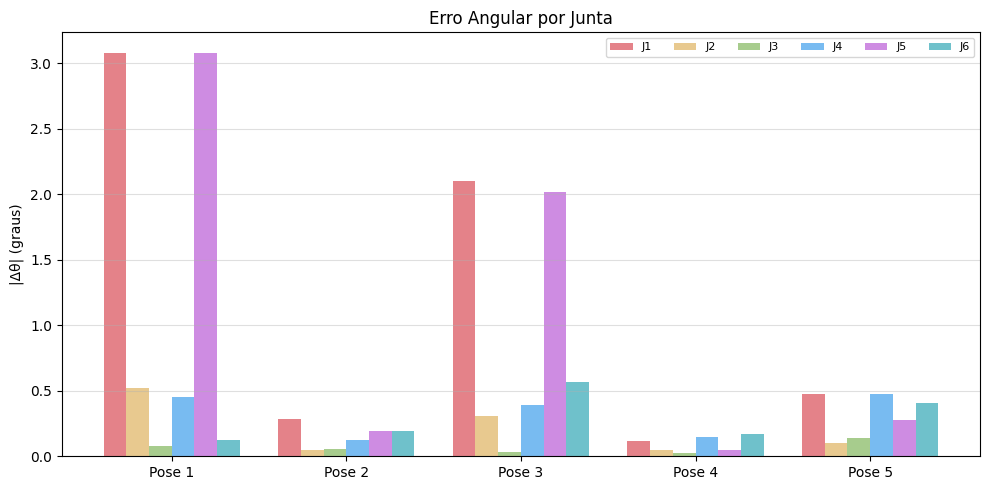

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = [f'Pose {i+1}' for i in range(len(results))]
x = np.arange(len(results))

width = 0.13
colors = ['#e06c75','#e5c07b','#98c379','#61afef','#c678dd','#56b6c2']
joint_labels = ['J1','J2','J3','J4','J5','J6']

for j in range(6):
    vals = [r['angle_err'][j] for r in results]
    offset = (j - 2.5) * width
    ax.bar(x + offset, vals, width,
           label=joint_labels[j], color=colors[j], alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('|Δθ| (graus)')
ax.set_title('Erro Angular por Junta')
ax.legend(ncol=6, fontsize=8)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
#plt.savefig('ik_erro_angular_junta.png', dpi=150, bbox_inches='tight')
plt.show()

  Sol  1 | shoulder left  | elbow up   | wrist down | θ = [166.5 -80.2   0.  124.4 118.6 -38.5]
  Sol  2 | shoulder left  | elbow down | wrist down | θ = [166.5 -80.2  -0.  124.4 118.6 -38.5]
  Sol  3 | shoulder left  | elbow up   | wrist up   | θ = [ 166.5 -121.4   67.4  -81.8 -118.6  141.5]
  Sol  4 | shoulder left  | elbow down | wrist up   | θ = [ 166.5  -57.   -67.4  -11.3 -118.6  141.5]
  Sol  5 | shoulder right | elbow up   | wrist down | θ = [  64.7 -107.5   24.   144.5   44.5 -115.5]
  Sol  6 | shoulder right | elbow down | wrist down | θ = [  64.7  -84.5  -24.   169.4   44.5 -115.5]
  Sol  7 | shoulder right | elbow up   | wrist up   | θ = [  64.7 -132.6   48.2  -34.6  -44.5   64.5]
  Sol  8 | shoulder right | elbow down | wrist up   | θ = [ 64.7 -86.5 -48.2  15.6 -44.5  64.5]

8 soluções para:
  pos = [0.197 0.024 0.728] m
  RPY = [150.  45.  90.]°


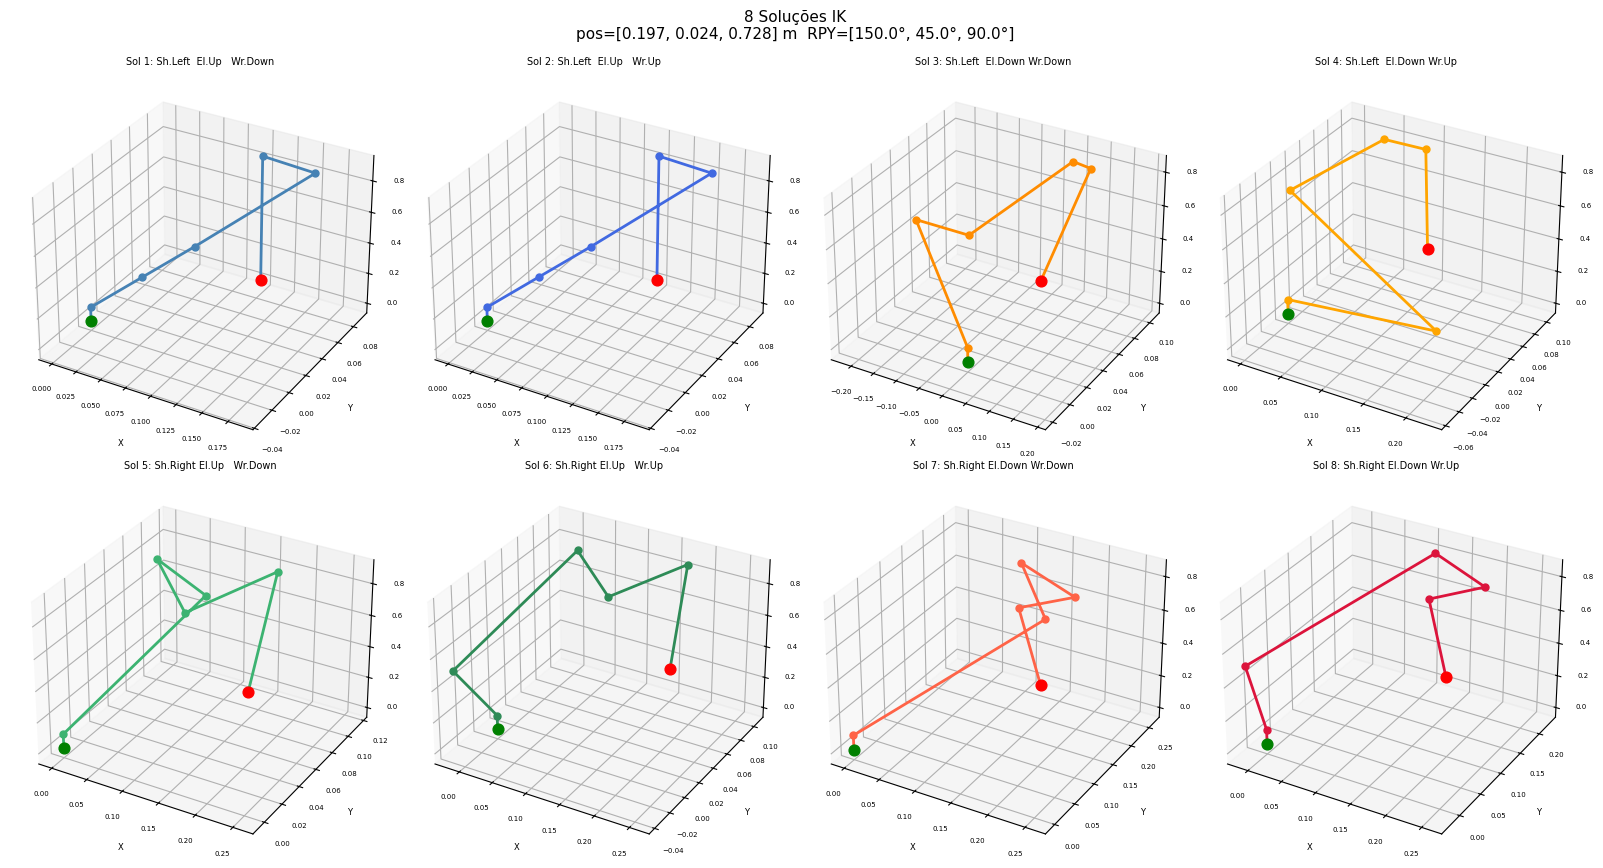

In [42]:
POSE_IDX = 4

pose_demo = test_poses[POSE_IDX]
T_demo, _ = fk_com_offset(pose_demo)
sols_demo = ik(T_demo, verbose=True)

# Posição e orientação do alvo
pos_alvo = T_demo[:3, 3]
rpy_alvo = rotation_to_rpy(T_demo[:3, :3])

print(f'\n{len(sols_demo)} soluções para:')
print(f'  pos = {np.round(pos_alvo, 3)} m')
print(f'  RPY = {np.round(rpy_alvo, 1)}°')

def plot_robot_3d(thetas_dh, ax, title='', color='steelblue'):
    """Plota cadeia cinemática 3D com posição do EE."""
    _, chain = fk(thetas_dh)
    pos = np.array([T[:3,3] for T in chain])
    
    ax.plot(pos[:,0], pos[:,1], pos[:,2], 'o-', color=color, lw=2, ms=5)
    ax.scatter(*pos[0],  color='green', s=60, zorder=5)
    ax.scatter(*pos[-1], color='red',   s=60, zorder=5)
    ax.set_title(title, fontsize=7)
    ax.set_xlabel('X', fontsize=6)
    ax.set_ylabel('Y', fontsize=6)
    ax.set_zlabel('Z', fontsize=6)
    ax.tick_params(labelsize=5)

fig = plt.figure(figsize=(16, 9))
fig.suptitle(
    f'8 Soluções IK\n'
    f'pos=[{pos_alvo[0]:.3f}, {pos_alvo[1]:.3f}, {pos_alvo[2]:.3f}] m  '
    f'RPY=[{rpy_alvo[0]:.1f}°, {rpy_alvo[1]:.1f}°, {rpy_alvo[2]:.1f}°]',
    fontsize=11)

configs = [
    'Sh.Left  El.Up   Wr.Down',
    'Sh.Left  El.Up   Wr.Up  ',
    'Sh.Left  El.Down Wr.Down',
    'Sh.Left  El.Down Wr.Up  ',
    'Sh.Right El.Up   Wr.Down',
    'Sh.Right El.Up   Wr.Up  ',
    'Sh.Right El.Down Wr.Down',
    'Sh.Right El.Down Wr.Up  ',
]
colors = ['steelblue','royalblue','darkorange','orange',
          'mediumseagreen','seagreen','tomato','crimson']

for j, (sol, cfg, col) in enumerate(zip(sols_demo, configs, colors)):
    ax = fig.add_subplot(2, 4, j+1, projection='3d')
    plot_robot_3d(sol, ax, title=f'Sol {j+1}: {cfg}', color=col)

plt.tight_layout()
plt.savefig('ik_8_solucoes.png', dpi=150, bbox_inches='tight')
plt.show()

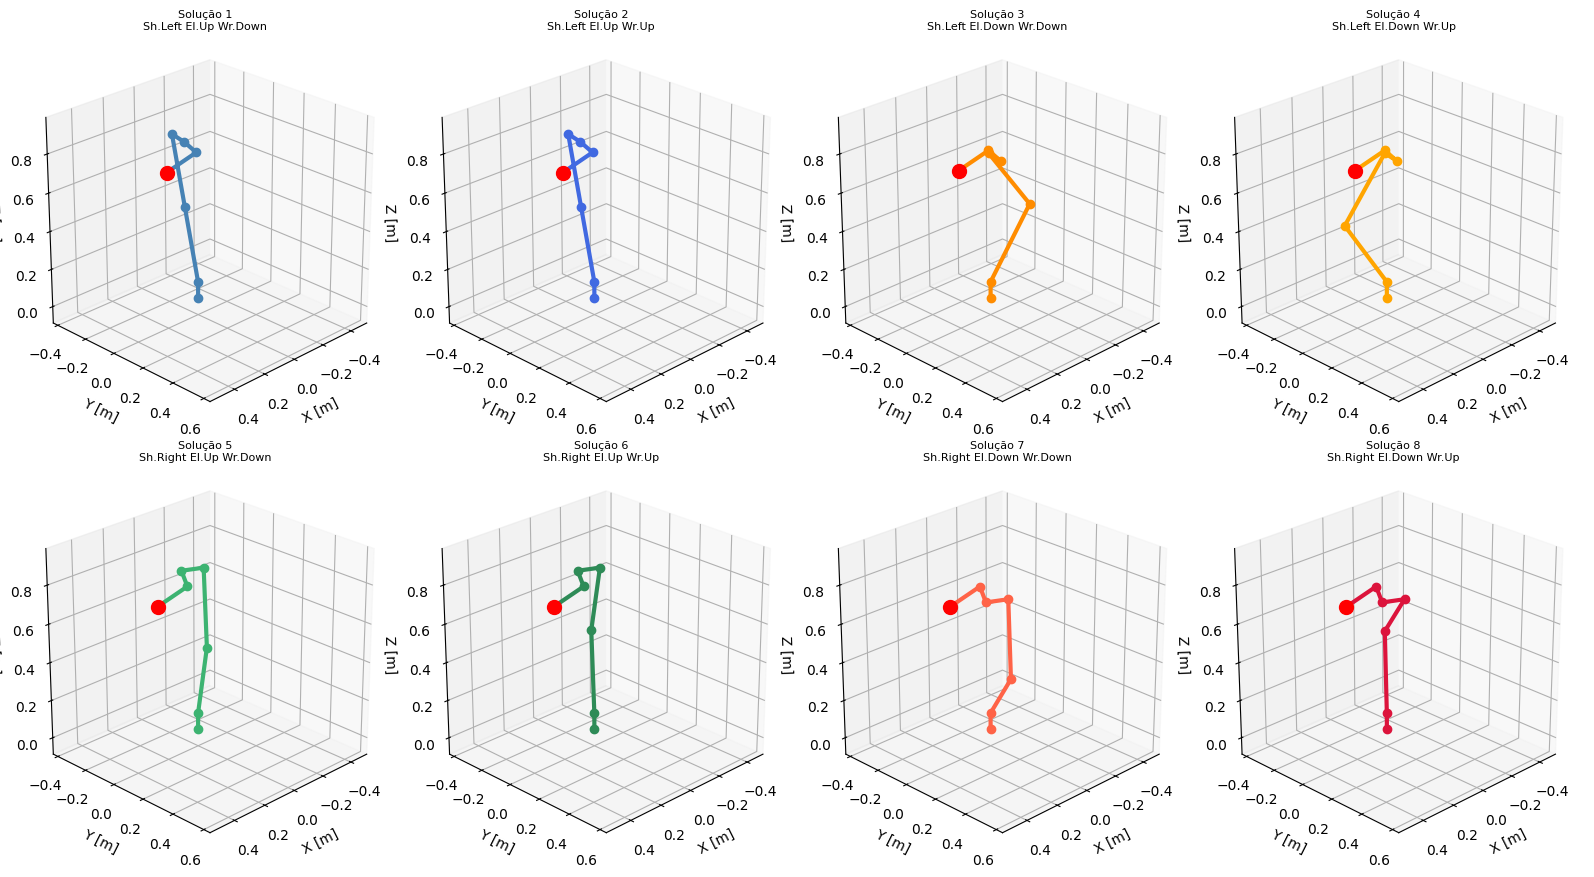

In [43]:
import numpy as np
import matplotlib.pyplot as plt


def draw_frame(ax, T, scale=0.05):
    """Desenha o frame local de uma transformação homogênea."""

    p = T[:3, 3]
    ax.quiver(p[0], p[1], p[2], T[0, 0], T[1, 0], T[2, 0], length=scale, normalize=True)
    ax.quiver(p[0], p[1], p[2], T[0, 1], T[1, 1], T[2, 1], length=scale, normalize=True)
    ax.quiver(p[0], p[1], p[2], T[0, 2], T[1, 2], T[2, 2], length=scale, normalize=True)

def plot_robot_3d(thetas_dh, ax, title='', color='steelblue', show_frames=True, show_labels=False, limits=None):
    """
    Plota uma configuração do UR5.
    """

    T_ee, chain = fk(thetas_dh)
    pos = np.array([T[:3, 3] for T in chain])
    # Links
    ax.plot(pos[:, 0], pos[:, 1], pos[:, 2], '-o', color=color, linewidth=3, markersize=6)

    # End-effector destacado
    ax.scatter(pos[-1, 0], pos[-1, 1], pos[-1, 2], s=100, color='red', zorder=10)

    if show_labels:
        for i, p in enumerate(pos):
            ax.text(p[0], p[1], p[2], f'J{i}', fontsize=8)

    if show_frames:
        for T in chain:
            draw_frame(ax, T, scale=0.05)

    if limits is not None:
        xmin, xmax, ymin, ymax, zmin, zmax = limits
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_zlim(zmin, zmax)

    ax.set_box_aspect([1, 1, 1])

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')

    ax.set_title(title, fontsize=8)
    ax.view_init(elev=25, azim=45)
    ax.grid(True)

    return pos


def compute_global_limits(solutions):
    """
    Calcula limites globais para todas as soluções.
    """

    all_points = []

    for sol in solutions:

        _, chain = fk(sol)

        pos = np.array([T[:3, 3] for T in chain])

        all_points.append(pos)

    all_points = np.vstack(all_points)

    xyz_min = np.min(all_points, axis=0)
    xyz_max = np.max(all_points, axis=0)

    center = (xyz_min + xyz_max) / 2

    radius = np.max(xyz_max - xyz_min) / 2

    radius *= 1.2

    radius = max(radius, 0.5)

    return (
        center[0] - radius,
        center[0] + radius,
        center[1] - radius,
        center[1] + radius,
        center[2] - radius,
        center[2] + radius
    )


# =====================================================
# PLOT DAS SOLUÇÕES
# =====================================================

configs = [
    'Sh.Left El.Up Wr.Down',
    'Sh.Left El.Up Wr.Up',
    'Sh.Left El.Down Wr.Down',
    'Sh.Left El.Down Wr.Up',
    'Sh.Right El.Up Wr.Down',
    'Sh.Right El.Up Wr.Up',
    'Sh.Right El.Down Wr.Down',
    'Sh.Right El.Down Wr.Up'
]

colors = [
    'steelblue',
    'royalblue',
    'darkorange',
    'orange',
    'mediumseagreen',
    'seagreen',
    'tomato',
    'crimson'
]

# supondo que suas soluções estejam em sols_demo
limits = compute_global_limits(sols_demo)

fig = plt.figure(figsize=(16, 9))

for j, sol in enumerate(sols_demo):
    ax = fig.add_subplot(2, 4, j + 1, projection='3d')
    cfg = configs[j] if j < len(configs) else f'Sol {j+1}'
    col = colors[j % len(colors)]
    plot_robot_3d(sol, ax, title=f'Solução {j+1}\n{cfg}', color=col, show_frames=False, show_labels=False, limits=limits)

plt.tight_layout()
plt.show()